In [30]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as cticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

## directory where to save or look for data
current_dir = "/home/paaa/python_scripts"
out_dir     = "/perm/paaa/images/CATRINE"
data_dir    = "/scratch/paaa/glob_co2_compare"

os.makedirs(data_dir, exist_ok=True)
os.makedirs(out_dir, exist_ok=True)

inidate="20220518"
enddate="20220520"
initime="0"
step="0/1/2/3/4/5/6/7/8/9/10/11/12/13/14/15/16/17/18/19/20/21/22/23" # in UTC

day_hours   = [8, 19] # in local time  (currently unused — define intent to use)
night_hours = [7, 20] # in local time  (currently unused — define

plot_date = inidate  # initialization date for the snapshot map (YYYYMMDD)
plot_step = 5        # forecast step (hours) for the snapshot map

runids = [
    ("iyw7", "Control",          "#244865"),  # blue
    # ("j1m9", "05 diff, stable",          "#e41a1c"),  # red
]

experiments_srf = {}
experiments_ml = {}

cabauw = {
    "lat": 51.971,
    "lon": 4.927,
}
loobos = {
    "lat": 52.1665,
    "lon": 5.7435,
}


In [31]:
def concentration_to_ppm(gas,concentration):
    """
    Convert concentration of co2 to ppm 
    Input:
         gas = name of the gas 
         concentration    = concentration in g/g
    """
    if gas == 'co2':
        mmgas=44.0095 # g/mol
    elif gas =='ra':
        mmgas=222 # g/mol
    elif gas =='ch4':
        mmgas=16.04 # g/mol
    else:
        raise ValueError("Gas wrongly specified or not known.")
    
    mmair=28.9644 #g/mol # assumption of dry air
    ppm = 10**6 *concentration * mmair/mmgas 
    return ppm

def wrap_lon(lon):
    lon = float(lon)
    if lon > 180:
        lon -= 360
    return lon

In [32]:
# Surface level
for (runid, _, _) in runids:
    print(f"###### Processing {runid} ######")
    target_file = f'{data_dir}/{runid}_sfc_europe_{inidate}to{enddate}.grib'
    if not os.path.exists(target_file):
        print(f"grib not found for {runid} SFC. Retrieving from MARS...")
        req_file = f"{current_dir}/mars_request_{runid}_sfc"
        req = {
            "class":   "rd",
            "type":    "fc",
            "date":    f"{inidate}/to/{enddate}",
            "expver":  runid,
            "param":   "2t/blh/64.210/65.210/80.228/210061/210062",
            "step":    step,
            "stream":  "oper",
            "time":    initime,
            "grid":    "0.2/0.2",
            "area":    "70/-20/30/50",  # N/W/S/E — Europe
            "levtype": "sfc",
            "target":  f'"{target_file}"',
        }
        kv = ['{}={}'.format(k, v) for k, v in req.items()]
        kv = 'retrieve,{}'.format(','.join(kv))
        print(kv)
        with open(req_file, "w") as f:
            f.write(kv)
        os.system(f"sbatch --mem='32GB' --wrap='mars {req_file}'")
    else:
        print(f"grib already exists for {runid} surface.")


###### Processing iyw7 ######
grib already exists for iyw7 surface.


In [33]:
experiments_srf["2t"]      = {}
experiments_srf["blh"]     = {}
experiments_srf["co2"]     = {}
experiments_srf["co2_ppm"] = {}

for (runid, _, _) in runids:
    target_file = f'{data_dir}/{runid}_sfc_europe_{inidate}to{enddate}.grib'

    ds_t = xr.open_dataset(target_file, engine='cfgrib',
                           filter_by_keys={'shortName': '2t'})
    experiments_srf["2t"][runid] = ds_t['t2m']

    ds_blh = xr.open_dataset(target_file, engine='cfgrib',
                              filter_by_keys={'shortName': 'blh'})
    experiments_srf["blh"][runid] = ds_blh['blh']

    ds_co2 = xr.open_dataset(target_file, engine='cfgrib',
                              filter_by_keys={'shortName': 'co2', 'typeOfLevel': 'surface'})
    experiments_srf["co2"][runid] = ds_co2['co2']
    experiments_srf["co2_ppm"][runid] = xr.DataArray(
        concentration_to_ppm('co2', ds_co2['co2'].values),
        coords=ds_co2['co2'].coords,
        dims=ds_co2['co2'].dims,
    )


In [34]:
# A few model levels
for (runid, _, _) in runids:
    print(f"###### Processing {runid} ######")
    target_file = f'{data_dir}/{runid}_ml_europe_{inidate}to{enddate}.grib'
    if not os.path.exists(target_file):
        print(f"grib not found for {runid} ml. Retrieving from MARS...")
        req_file = f"{current_dir}/mars_request_{runid}_ml"
        req = {
            "class":    "rd",
            "type":     "fc",
            "date":     f"{inidate}/to/{enddate}",
            "expver":   runid,
            "param":    "co2/ch4",
            "levelist": "120/125/130/137",
            "step":     step,
            "stream":   "oper",
            "time":     initime,
            "grid":     "0.2/0.2",
            "area":     "70/-20/30/50",  # N/W/S/E — Europe
            "levtype":  "ml",
            "target":   f'"{target_file}"',
        }
        kv = ['{}={}'.format(k, v) for k, v in req.items()]
        kv = 'retrieve,{}'.format(','.join(kv))
        print(kv)
        with open(req_file, "w") as f:
            f.write(kv)
        os.system(f"sbatch --mem='32GB' --wrap='mars {req_file}'")
    else:
        print(f"grib already exists for {runid} model levels.")


###### Processing iyw7 ######
grib already exists for iyw7 model levels.


In [35]:
# Wind components (u, v) on model level 137
for (runid, _, _) in runids:
    print(f"###### Processing {runid} winds ######")
    target_file = f'{data_dir}/{runid}_wind137_europe_{inidate}to{enddate}.grib'
    if not os.path.exists(target_file):
        print(f"grib not found for {runid} wind ml. Retrieving from MARS...")
        req_file = f"{current_dir}/mars_request_{runid}_wind137"
        req = {
            "class":    "rd",
            "type":     "fc",
            "date":     f"{inidate}/to/{enddate}",
            "expver":   runid,
            "param":    "u/v",
            "levelist": "137",
            "step":     step,
            "stream":   "oper",
            "time":     initime,
            "grid":     "0.2/0.2",
            "area":     "70/-20/30/50",  # N/W/S/E — Europe
            "levtype":  "ml",
            "target":   f'"{target_file}"',
        }
        kv = ['{}={}'.format(k, v) for k, v in req.items()]
        kv = 'retrieve,{}'.format(','.join(kv))
        print(kv)
        with open(req_file, "w") as f:
            f.write(kv)
        os.system(f"sbatch --mem='32GB' --wrap='mars {req_file}'")
    else:
        print(f"grib already exists for {runid} wind ml.")


###### Processing iyw7 winds ######
grib already exists for iyw7 wind ml.


In [36]:
experiments_ml = {f"co2_{l}": {} for l in ["137", "130", "125", "120"]}
experiments_ml["co2_137_ppm"] = {}

for runid, _, _ in runids:
    target_file = f'{data_dir}/{runid}_ml_europe_{inidate}to{enddate}.grib'
    # Load all CO2 levels at once; cfgrib creates a 'hybrid' coordinate for model levels
    ds = xr.open_dataset(target_file, engine='cfgrib',
                         filter_by_keys={'shortName': 'co2', 'typeOfLevel': 'hybrid'})
    for level in ["137", "130", "125", "120"]:
        experiments_ml[f"co2_{level}"][runid] = ds['co2'].sel(hybrid=int(level))

    # Convert level 137 to ppm
    co2_kg = experiments_ml["co2_137"][runid]
    experiments_ml["co2_137_ppm"][runid] = xr.DataArray(
        concentration_to_ppm('co2', co2_kg.values),
        coords=co2_kg.coords,
        dims=co2_kg.dims,
    )


In [37]:
# Extract u and v winds on model level 137
experiments_ml["u_137"] = {}
experiments_ml["v_137"] = {}

for runid, _, _ in runids:
    target_file = f'{data_dir}/{runid}_wind137_europe_{inidate}to{enddate}.grib'
    # u and v may land in separate datasets due to different GRIB keys
    ds_u = xr.open_dataset(target_file, engine='cfgrib',
                            filter_by_keys={'shortName': 'u', 'typeOfLevel': 'hybrid', 'level': 137})
    ds_v = xr.open_dataset(target_file, engine='cfgrib',
                            filter_by_keys={'shortName': 'v', 'typeOfLevel': 'hybrid', 'level': 137})
    experiments_ml["u_137"][runid] = ds_u['u']
    experiments_ml["v_137"][runid] = ds_v['v']


## PLOT

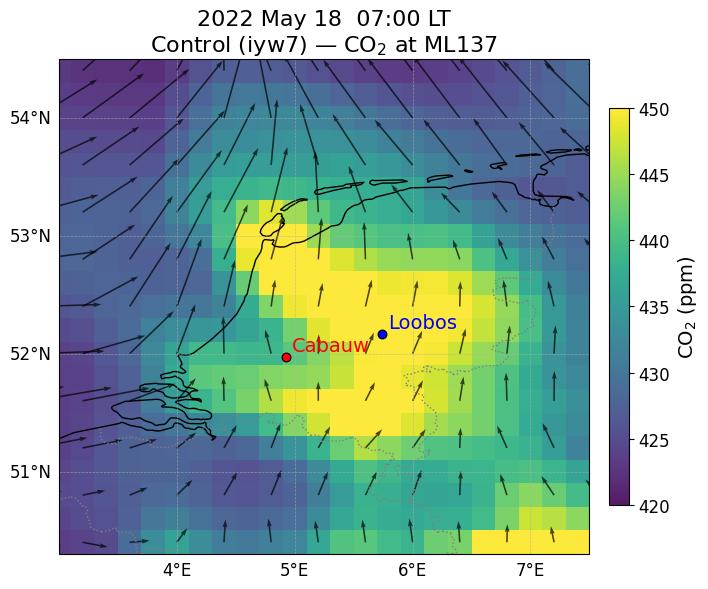

In [38]:
########################
########  Maps  ########
########################
from datetime import datetime, timedelta, timezone
import numpy as np

runid, name, color = runids[0]

# Compute valid time (UTC+2) from plot_date, initime and plot_step
utc_dt = datetime(int(plot_date[:4]), int(plot_date[4:6]), int(plot_date[6:8]),
                  int(initime), tzinfo=timezone.utc) + timedelta(hours=plot_step)
local_dt = utc_dt + timedelta(hours=2)
local_time_str = local_dt.strftime("%Y %b %d  %H:%M LT")

# CO2 in ppm at model level 137 — select specific (init date, forecast step)
co2_ppm = experiments_ml["co2_137_ppm"][runid]
plot_init_np = np.datetime64(
    f"{plot_date[:4]}-{plot_date[4:6]}-{plot_date[6:8]}T{int(initime):02d}:00")
sel_kw = {}
if 'time' in co2_ppm.dims:
    sel_kw['time'] = plot_init_np
if 'step' in co2_ppm.dims:
    sel_kw['step'] = np.timedelta64(plot_step, 'h')
co2_ppm_snap = co2_ppm.sel(**sel_kw).squeeze()
lats = co2_ppm_snap.latitude.values
lons = co2_ppm_snap.longitude.values
co2_data = co2_ppm_snap.values

# Winds at model level 137 — same selection
ds_u = experiments_ml["u_137"][runid]
ds_v = experiments_ml["v_137"][runid]
u_data = ds_u.sel(**{k: v for k, v in sel_kw.items() if k in ds_u.dims}).squeeze().values
v_data = ds_v.sel(**{k: v for k, v in sel_kw.items() if k in ds_v.dims}).squeeze().values

# Define the projection
projection = ccrs.PlateCarree()

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': projection})

# Plot CO2 field
vmin = 420
vmax = 450
mesh = ax.pcolormesh(lons, lats, co2_data, cmap='viridis', alpha=0.9,
                     vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())

# Add colorbar
cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
cbar.set_label("CO$_2$ (ppm)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

# Add coastlines and borders
ax.coastlines(resolution='10m', linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')

# Set extent to focus on the Netherlands region
ax.set_extent([3, 7.5, 50.3, 54.5], crs=ccrs.PlateCarree())
# ax.set_extent([4.45, 5.92, 51.6, 52.5], crs=ccrs.PlateCarree())

# Add gridlines with labels
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, alpha=0.7)
gl.top_labels = False
gl.right_labels = False
gl.xlocator = cticker.MaxNLocator(5)
gl.ylocator = cticker.MaxNLocator(5)
gl.xlabel_style = {"size": 12, "color": "black"}
gl.ylabel_style = {"size": 12, "color": "black"}

# Wind arrows at model level 137 (subsampled to avoid overcrowding)
skip = 2
ax.quiver(lons[::skip], lats[::skip],
          u_data[::skip, ::skip], v_data[::skip, ::skip],
          transform=ccrs.PlateCarree(), scale=50, color='k', alpha=0.7, width=0.003)

# Cabauw
ax.scatter(cabauw['lon'], cabauw['lat'], color='red', s=40, marker='o',
           transform=ccrs.PlateCarree(), edgecolor='black', linewidth=0.8, zorder=5)
ax.text(cabauw['lon'] + 0.05, cabauw['lat'] + 0.05, 'Cabauw',
        color='red', fontsize=14, transform=ccrs.PlateCarree())

# Loobos
ax.scatter(loobos['lon'], loobos['lat'], color='blue', s=40, marker='o',
           transform=ccrs.PlateCarree(), edgecolor='black', linewidth=0.8, zorder=5)
ax.text(loobos['lon'] + 0.05, loobos['lat'] + 0.05, 'Loobos',
        color='blue', fontsize=14, transform=ccrs.PlateCarree())

plt.title(f"{local_time_str}\n{name} ({runid}) — CO$_2$ at ML137", fontsize=16)
plt.tight_layout()
os.makedirs(out_dir, exist_ok=True)
plt.savefig(f"{out_dir}/{runid}_co2_ml137_europe_{plot_date}_{plot_step}h.png",
            dpi=150, bbox_inches='tight')
plt.show()


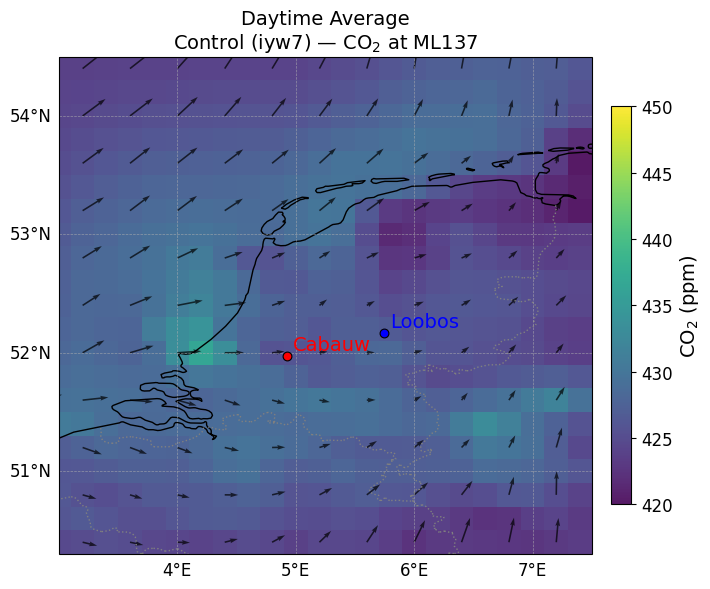

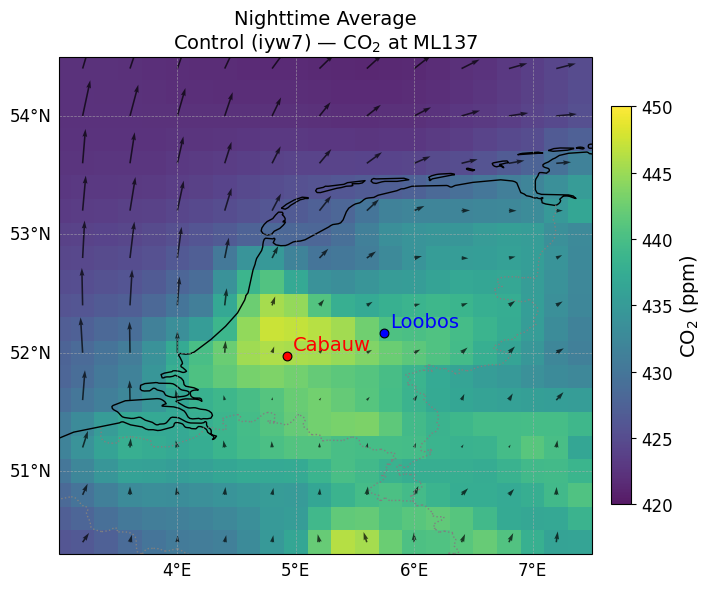

In [39]:

########################
##  Day / Night Maps  ##
########################
from datetime import datetime, timedelta, timezone
import numpy as np
import pandas as pd

UTC_OFFSET = 2  # hours ahead of UTC for the Netherlands

runid, name, color = runids[0]

def filtered_mean(da, h_min, h_max, night=False):
    """
    Average da over timesteps whose local hour satisfies the filter.
      night=False (day):  h_min <= local_hour <= h_max
      night=True:         local_hour < h_min  OR  local_hour >= h_max
    """
    spatial_dims = {'latitude', 'longitude', 'hybrid'}
    time_dims = [d for d in da.dims if d not in spatial_dims]
    if not time_dims:
        return da
    # Compute valid_time by broadcasting init time + forecast step
    if 'time' in da.dims and 'step' in da.dims:
        vt = da.time + da.step          # broadcasts to (time, step)
    elif 'valid_time' in da.coords:
        vt = da.valid_time
    else:
        return da.mean(dim=time_dims)
    local_hour = (vt + pd.Timedelta(hours=UTC_OFFSET)).dt.hour
    if night:
        mask = (local_hour < h_min) | (local_hour >= h_max)
    else:
        mask = (local_hour >= h_min) & (local_hour <= h_max)
    return da.where(mask).mean(dim=time_dims)

# Build time-range label (inidate+step[0] → enddate+step[-1])
steps = [int(s) for s in step.split("/")]
utc_start = datetime(int(inidate[:4]), int(inidate[4:6]), int(inidate[6:8]),
                     int(initime), tzinfo=timezone.utc) + timedelta(hours=steps[0])
utc_end   = datetime(int(enddate[:4]), int(enddate[4:6]), int(enddate[6:8]),
                     int(initime), tzinfo=timezone.utc) + timedelta(hours=steps[-1])
time_range_str = (f"{utc_start.strftime('%Y %b %d %H:%M')} – "
                  f"{utc_end.strftime('%Y %b %d %H:%M')} UTC")

# ---- Compute averages ----
# day_hours  = [h_start, h_end]:              day   if h_start <= local_hour <= h_end
# night_hours = [h_morning_end, h_eve_start]: night if local_hour < h_morning_end
#                                                   OR local_hour >= h_eve_start
co2_ppm_all = experiments_ml["co2_137_ppm"][runid]
u_all       = experiments_ml["u_137"][runid]
v_all       = experiments_ml["v_137"][runid]

co2_day = filtered_mean(co2_ppm_all, day_hours[0],   day_hours[1],   night=False)
co2_ngt = filtered_mean(co2_ppm_all, night_hours[0], night_hours[1], night=True)
u_day   = filtered_mean(u_all,       day_hours[0],   day_hours[1],   night=False)
v_day   = filtered_mean(v_all,       day_hours[0],   day_hours[1],   night=False)
u_ngt   = filtered_mean(u_all,       night_hours[0], night_hours[1], night=True)
v_ngt   = filtered_mean(v_all,       night_hours[0], night_hours[1], night=True)

lats = co2_day.latitude.values
lons = co2_day.longitude.values
vmin, vmax = 420, 450

def make_avg_map(ax, co2_data, u_data, v_data, title):
    mesh = ax.pcolormesh(lons, lats, co2_data, cmap='viridis', alpha=0.9,
                         vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
    cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
    cbar.set_label("CO$_2$ (ppm)", fontsize=14)
    cbar.ax.tick_params(labelsize=12)
    ax.coastlines(resolution='10m', linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')
    ax.set_extent([3, 7.5, 50.3, 54.5], crs=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, alpha=0.7)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = cticker.MaxNLocator(5)
    gl.ylocator = cticker.MaxNLocator(5)
    gl.xlabel_style = {"size": 12, "color": "black"}
    gl.ylabel_style = {"size": 12, "color": "black"}
    skip = 2
    ax.quiver(lons[::skip], lats[::skip],
              u_data[::skip, ::skip], v_data[::skip, ::skip],
              transform=ccrs.PlateCarree(), scale=50, color='k', alpha=0.7, width=0.003)
    ax.scatter(cabauw['lon'], cabauw['lat'], color='red', s=40, marker='o',
               transform=ccrs.PlateCarree(), edgecolor='black', linewidth=0.8, zorder=5)
    ax.text(cabauw['lon'] + 0.05, cabauw['lat'] + 0.05, 'Cabauw',
            color='red', fontsize=14, transform=ccrs.PlateCarree())
    ax.scatter(loobos['lon'], loobos['lat'], color='blue', s=40, marker='o',
               transform=ccrs.PlateCarree(), edgecolor='black', linewidth=0.8, zorder=5)
    ax.text(loobos['lon'] + 0.05, loobos['lat'] + 0.05, 'Loobos',
            color='blue', fontsize=14, transform=ccrs.PlateCarree())
    ax.set_title(title, fontsize=14)

os.makedirs(out_dir, exist_ok=True)

# ---- Daytime average ----
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
make_avg_map(ax, co2_day.values, u_day.values, v_day.values,
             f"Daytime Average\n"
             f"{name} ({runid}) — CO$_2$ at ML137"
            #  f"{time_range_str}"
            #  f"  |  local {day_hours[0]:02d}:00–{day_hours[1]:02d}:00 LT"
            )
plt.tight_layout()
plt.savefig(f"{out_dir}/{runid}_co2_ml137_europe_{inidate}to{enddate}_day_avg.png",
            dpi=150, bbox_inches='tight')
plt.show()

# ---- Nighttime average ----
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
make_avg_map(ax, co2_ngt.values, u_ngt.values, v_ngt.values,
             f"Nighttime Average\n"
             f"{name} ({runid}) — CO$_2$ at ML137"
            #  f"{time_range_str}"
            #  f"  |  local 00:00–{night_hours[0]:02d}:00 & {night_hours[1]:02d}:00–23:59 LT"
             )
plt.tight_layout()
plt.savefig(f"{out_dir}/{runid}_co2_ml137_europe_{inidate}to{enddate}_night_avg.png",
            dpi=150, bbox_inches='tight')
plt.show()


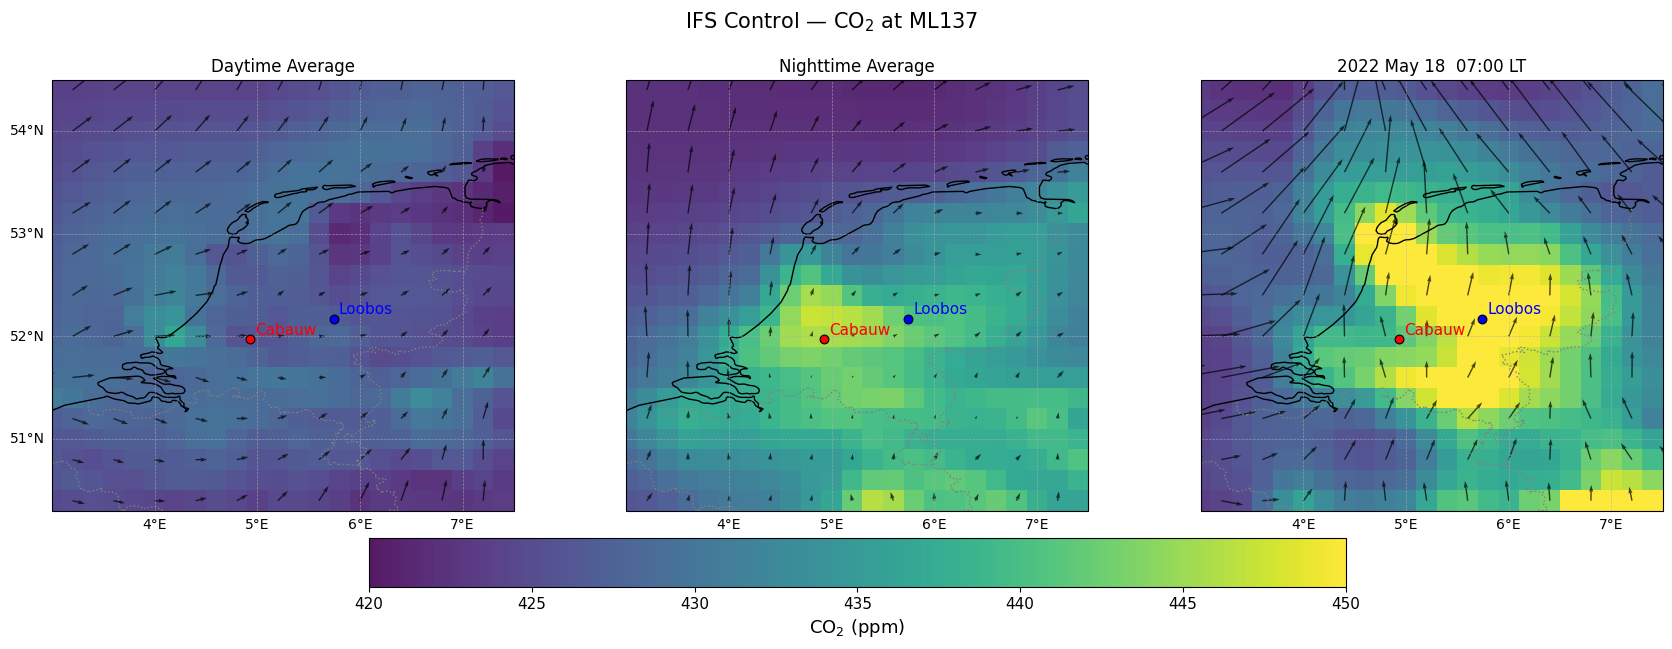

In [49]:

# Side-by-side: Daytime | Nighttime | Snapshot
vmin, vmax = 420, 450

panels = [
    (co2_day.values, u_day.values, v_day.values,
     f"Daytime Average"),
    (co2_ngt.values, u_ngt.values, v_ngt.values,
     f"Nighttime Average"),
    (co2_data,       u_data,       v_data,
     local_time_str),
]

fig, axes = plt.subplots(1, 3, figsize=(21, 7),
                          subplot_kw={'projection': ccrs.PlateCarree()})

mesh = None
for i, (ax, (co2, u, v, title)) in enumerate(zip(axes, panels)):
    mesh = ax.pcolormesh(lons, lats, co2, cmap='viridis', alpha=0.9,
                         vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
    ax.coastlines(resolution='10m', linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')
    ax.set_extent([3, 7.5, 50.3, 54.5], crs=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, alpha=0.7)
    gl.top_labels   = False
    gl.right_labels = False
    gl.left_labels  = (i == 0)   # y-labels only on leftmost panel
    gl.xlocator     = cticker.MaxNLocator(5)
    gl.ylocator     = cticker.MaxNLocator(5)
    gl.xlabel_style = {"size": 10, "color": "black"}
    gl.ylabel_style = {"size": 10, "color": "black"}
    skip = 2
    ax.quiver(lons[::skip], lats[::skip], u[::skip, ::skip], v[::skip, ::skip],
              transform=ccrs.PlateCarree(), scale=50, color='k', alpha=0.7, width=0.003)
    ax.scatter(cabauw['lon'], cabauw['lat'], color='red', s=40, marker='o',
               transform=ccrs.PlateCarree(), edgecolor='black', linewidth=0.8, zorder=5)
    ax.text(cabauw['lon'] + 0.05, cabauw['lat'] + 0.05, 'Cabauw',
            color='red', fontsize=11, transform=ccrs.PlateCarree())
    ax.scatter(loobos['lon'], loobos['lat'], color='blue', s=40, marker='o',
               transform=ccrs.PlateCarree(), edgecolor='black', linewidth=0.8, zorder=5)
    ax.text(loobos['lon'] + 0.05, loobos['lat'] + 0.05, 'Loobos',
            color='blue', fontsize=11, transform=ccrs.PlateCarree())
    ax.set_title(title, fontsize=12)

# Common colorbar — horizontal below the panels
cbar = fig.colorbar(mesh, ax=axes.tolist(), orientation='horizontal', shrink=0.6, pad=0.05)
cbar.set_label("CO$_2$ (ppm)", fontsize=13)
cbar.ax.tick_params(labelsize=11)

# Common suptitle (no repetition across panels)
fig.suptitle(f"IFS {name} — CO$_2$ at ML137", fontsize=15, y=0.98)

plt.savefig(f"{out_dir}/{runid}_co2_ml137_europe_{inidate}to{enddate}_panels.png",
            dpi=150, bbox_inches='tight')
plt.show()
